In [1]:
#imports
import sqlite3, pandas as pd, numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

conn = sqlite3.connect("restaurant.db")

In [2]:
#Data validation
checks = {
    "orphan_order_items": "SELECT COUNT(*) FROM order_items oi LEFT JOIN orders o ON oi.order_id=o.order_id WHERE o.order_id IS NULL",
    "negative_quantities": "SELECT COUNT(*) FROM order_items WHERE quantity <= 0",
}
for name, q in checks.items():
    print(name, ":", pd.read_sql(q, conn).iloc[0,0], "issues")

orphan_order_items : 0 issues
negative_quantities : 0 issues


Contribution Margin/dish 

In [6]:
query_margin = """
WITH dish_cost AS (
    SELECT di.dish_id, SUM(di.quantity_used * i.unit_cost) AS ingredient_cost
    FROM dish_ingredients di JOIN ingredients i ON di.ingredient_id = i.ingredient_id
    GROUP BY di.dish_id
)
SELECT d.dish_name, d.menu_price, dc.ingredient_cost,
       ROUND(d.menu_price - dc.ingredient_cost, 2) AS contribution_margin,
       ROUND((d.menu_price - dc.ingredient_cost) / d.menu_price * 100, 2) AS margin_pct
FROM dishes d JOIN dish_cost dc ON d.dish_id = dc.dish_id
ORDER BY margin_pct DESC
"""
df_margin = pd.read_sql(query_margin, conn)
df_margin

,dish_name,menu_price,ingredient_cost,contribution_margin,margin_pct
0,Caesar Salad,11.99,0.275,11.71,97.71
1,French Fries,5.99,0.300,5.69,94.99
2,Classic Cheeseburger,13.99,1.330,12.66,90.49
3,Grilled Chicken Sandwich,14.99,1.470,13.52,90.19
4,Fish Tacos,16.99,2.160,14.83,87.29
5,Chocolate Lava Cake,8.99,1.200,7.79,86.65
6,Margherita Pizza,15.99,2.490,13.50,84.43
7,Buffalo Wings,12.99,2.280,10.71,82.45


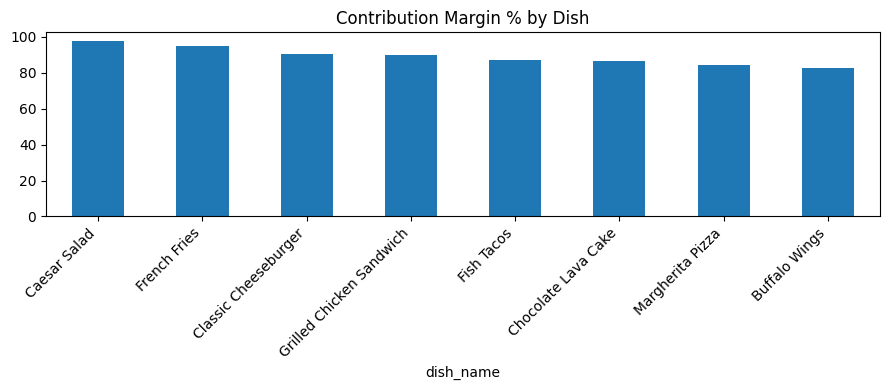

In [7]:
#Margin Chart
df_margin.plot(x="dish_name", y="margin_pct", kind="bar", figsize=(9,4), legend=False)
plt.title("Contribution Margin % by Dish"); plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.savefig("chart_margin.png", dpi=120); plt.show()

Food Cost Rolling Average

In [31]:
query_food_cost = """
WITH daily_food_cost AS (
    SELECT o.location_id, o.order_date,
           SUM(oi.quantity * di.quantity_used * i.unit_cost) AS daily_ingredient_cost
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id
    JOIN dish_ingredients di ON oi.dish_id = di.dish_id
    JOIN ingredients i ON di.ingredient_id = i.ingredient_id
    GROUP BY o.location_id, o.order_date
)
SELECT location_id, order_date, daily_ingredient_cost FROM daily_food_cost ORDER BY location_id, order_date
"""
df_food_cost = pd.read_sql(query_food_cost, conn, parse_dates=["order_date"])
df_food_cost["rolling_7day_avg"] = df_food_cost.groupby("location_id")["daily_ingredient_cost"].transform(lambda s: s.rolling(7, min_periods=1).mean())
df_food_cost.tail()

,location_id,order_date,daily_ingredient_cost,rolling_7day_avg
4379,8,2025-11-26,95.785,106.905714
4380,8,2025-11-27,65.645,104.234286
4381,8,2025-11-28,210.790,116.494286
4382,8,2025-11-29,163.625,119.964286
4383,8,2025-11-30,143.110,125.525714


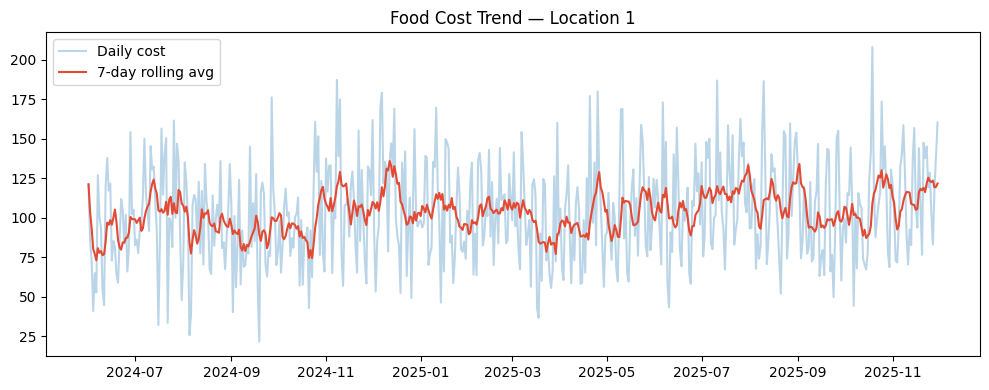

In [32]:
#food cost trend chart
loc1 = df_food_cost[df_food_cost.location_id == 1]
plt.figure(figsize=(10,4))
plt.plot(loc1.order_date, loc1.daily_ingredient_cost, alpha=0.3, label="Daily cost")
plt.plot(loc1.order_date, loc1.rolling_7day_avg, color="#e34a33", label="7-day rolling avg")
plt.title("Food Cost Trend — Location 1"); plt.legend()
plt.tight_layout(); plt.savefig("chart_food_cost_trend.png", dpi=120); plt.show()

labor cost % of revenue (cross-system reconciliation)

In [33]:
query_labor = """
WITH labor_cost AS (
    SELECT location_id, strftime('%Y-%m', work_date) AS month, SUM(hours_worked*hourly_rate) AS total_labor_cost
    FROM labor_hours GROUP BY location_id, month
),
revenue AS (
    SELECT o.location_id, strftime('%Y-%m', o.order_date) AS month, SUM(oi.quantity*oi.item_price) AS total_revenue
    FROM orders o JOIN order_items oi ON o.order_id = oi.order_id GROUP BY o.location_id, month
)
SELECT lc.location_id, lc.month, lc.total_labor_cost, r.total_revenue,
       ROUND(lc.total_labor_cost / r.total_revenue * 100, 2) AS labor_pct_of_revenue
FROM labor_cost lc JOIN revenue r ON lc.location_id=r.location_id AND lc.month=r.month
ORDER BY lc.location_id, lc.month
"""
df_labor = pd.read_sql(query_labor, conn)
df_labor.head(10)

,location_id,month,total_labor_cost,total_revenue,labor_pct_of_revenue
0,1,2024-06,42093.525,24078.18,174.82
1,1,2024-07,38973.458,28814.22,135.26
2,1,2024-08,41185.519,26216.54,157.10
3,1,2024-09,40232.833,23516.60,171.08
4,1,2024-10,41870.517,25407.05,164.80
5,1,2024-11,40394.067,29475.84,137.04
6,1,2024-12,41648.249,30772.03,135.34
7,1,2025-01,43410.553,28161.83,154.15
8,1,2025-02,37813.139,26182.62,144.42
9,1,2025-03,40665.490,26542.89,153.21


New Store Performance

In [34]:
query_new_store = """
SELECT l.location_id, l.location_name, l.open_date,
       COUNT(DISTINCT o.order_id) AS total_orders,
       ROUND(SUM(oi.quantity*oi.item_price),2) AS total_revenue
FROM locations l JOIN orders o ON l.location_id=o.location_id
JOIN order_items oi ON o.order_id=oi.order_id
GROUP BY l.location_id, l.location_name, l.open_date ORDER BY l.open_date DESC
"""
df_new_store = pd.read_sql(query_new_store, conn)
df_new_store

,location_id,location_name,open_date,total_orders,total_revenue
0,8,Lake Roberto Location,2023-09-06,12790,488043.89
1,1,North Judithbury Location,2023-08-22,13069,499230.80
2,3,New Roberttown Location,2023-08-18,12963,497874.61
3,7,Lisatown Location,2023-01-06,12887,493402.51
4,6,Robinsonshire Location,2022-08-23,12896,493605.65
5,5,Lake Debra Location,2022-03-28,13074,499640.39
6,4,East Jessetown Location,2022-01-01,13330,508931.32
7,2,East Jill Location,2021-07-25,12989,497386.85


monthly revenue base table

In [35]:
query_monthly_rev = """
SELECT o.location_id, strftime('%Y-%m', o.order_date) AS month, SUM(oi.quantity*oi.item_price) AS revenue
FROM orders o JOIN order_items oi ON o.order_id=oi.order_id GROUP BY o.location_id, month ORDER BY o.location_id, month
"""
df_rev = pd.read_sql(query_monthly_rev, conn)
df_rev.head()

,location_id,month,revenue
0,1,2024-06,24078.18
1,1,2024-07,28814.22
2,1,2024-08,26216.54
3,1,2024-09,23516.60
4,1,2024-10,25407.05


forecasting model

In [36]:
loc = 1
d = df_rev[df_rev.location_id == loc].reset_index(drop=True)
d["t"] = np.arange(len(d))
d["month_num"] = pd.to_datetime(d["month"]).dt.month

X = pd.get_dummies(d[["t","month_num"]], columns=["month_num"], drop_first=True)
y = d["revenue"]
X_train, X_test = X.iloc[:-3], X.iloc[-3:]
y_train, y_test = y.iloc[:-3], y.iloc[-3:]

model = LinearRegression().fit(X_train, y_train)
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
print(f"Test MAE: ${mae:,.0f} (avg monthly revenue: ${y_test.mean():,.0f})")

future_t = np.arange(len(d), len(d)+3)
future_month_num = [(d.month_num.iloc[-1] + i - 1) % 12 + 1 for i in range(1,4)]
future_X = pd.DataFrame({"t": future_t, "month_num": future_month_num})
future_X = pd.get_dummies(future_X, columns=["month_num"], drop_first=True).reindex(columns=X.columns, fill_value=0)
forecast = model.predict(future_X)
print("Next 3-month forecast:", [f"${v:,.0f}" for v in forecast])

Test MAE: $1,402 (avg monthly revenue: $28,632)
Next 3-month forecast: ['$34,371', '$31,761', '$29,782']


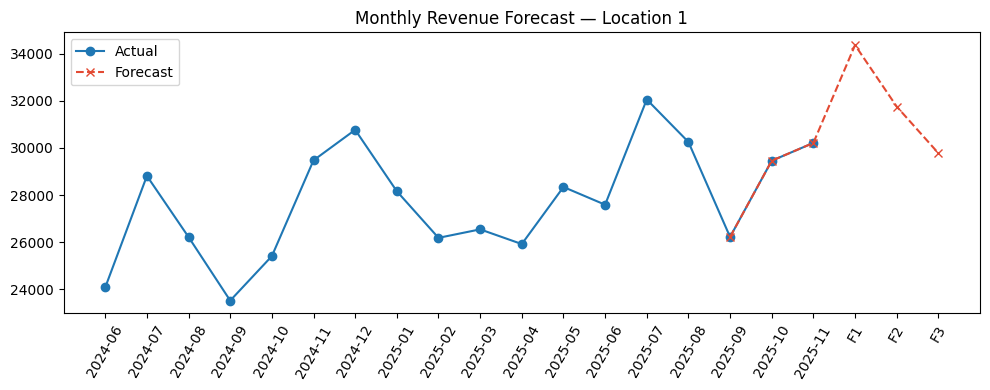

In [37]:
plt.figure(figsize=(10,4))
plt.plot(d.month, d.revenue, marker="o", label="Actual")
plt.plot(list(d.month.iloc[-3:]) + [f"F{i+1}" for i in range(3)],
         list(y_test) + list(forecast), linestyle="--", marker="x", color="#e34a33", label="Forecast")
plt.xticks(rotation=60); plt.title(f"Monthly Revenue Forecast — Location {loc}")
plt.legend(); plt.tight_layout(); plt.savefig("chart_forecast.png", dpi=120); plt.show()

Exporting everything for excel dashboard

In [38]:
df_margin.to_csv("out_margin.csv", index=False)
df_food_cost.to_csv("out_food_cost.csv", index=False)
df_labor.to_csv("out_labor.csv", index=False)
df_new_store.to_csv("out_new_store.csv", index=False)
df_rev.to_csv("out_monthly_revenue.csv", index=False)
pd.DataFrame({"month": [f"Forecast +{i+1}" for i in range(3)], "forecasted_revenue": forecast}).to_csv("out_forecast.csv", index=False)
print("All exports done — ready for the Excel dashboard.")

All exports done — ready for the Excel dashboard.
